Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn import metrics

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Data Collection & Analysis

In [3]:
# loading the data from csv file to a Pandas DataFrame
insurance_dataset = pd.read_csv('/content/drive/MyDrive/Study/Jhankar Mahbub/Phitron ML AI/Main course/ML without git/ML practice self/Machine Learning Projects/Regression/Insurance Cost Prediction/insurance.csv')

In [4]:
# first 5 rows of the dataframe
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# number of rows and columns
insurance_dataset.shape

(1338, 7)

In [6]:
# getting some informations about the dataset
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Categorical Features:
- Sex
- Smoker
- Region

In [7]:
# checking for missing values
insurance_dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Data Analysis

In [8]:
# statistical Measures of the dataset
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


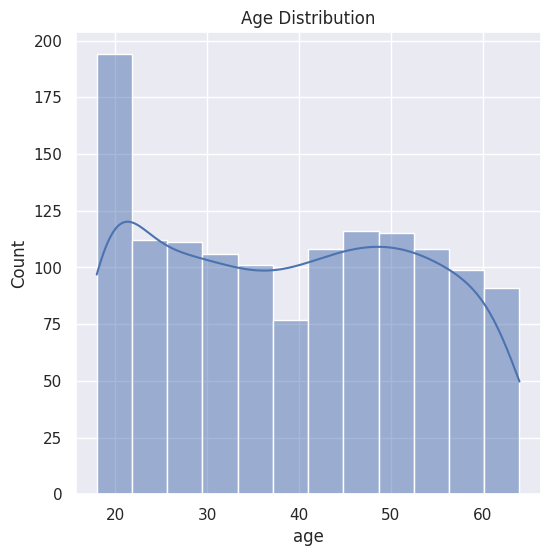

In [9]:
# distribution of age value
sns.set()
plt.figure(figsize=(6,6))
sns.histplot(insurance_dataset['age'], kde=True)
plt.title('Age Distribution')
plt.show()

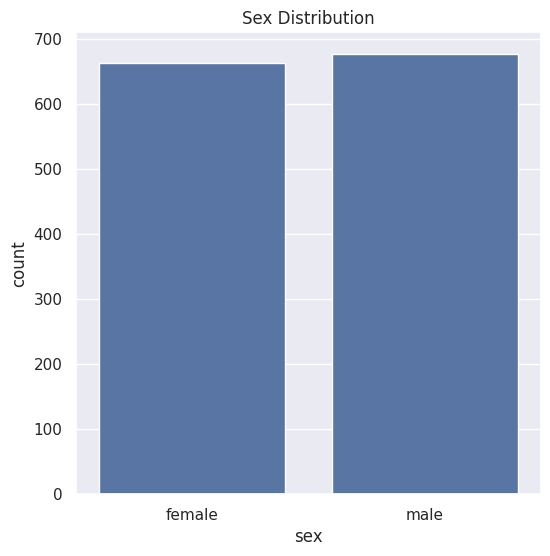

In [10]:
# Gender column
plt.figure(figsize=(6,6))
sns.countplot(x='sex', data=insurance_dataset)
plt.title('Sex Distribution')
plt.show()

In [11]:
insurance_dataset['sex'].value_counts()

,count
sex,
male,676
female,662


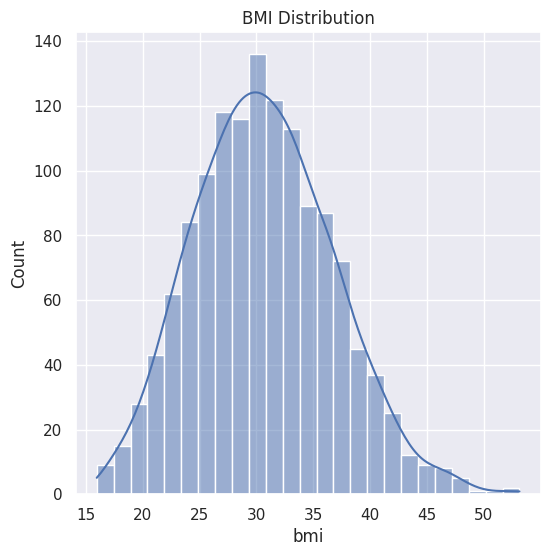

In [12]:
# bmi distribution
plt.figure(figsize=(6,6))
sns.histplot(insurance_dataset['bmi'], kde=True)
plt.title('BMI Distribution')
plt.show()

Normal BMI Range --> 18.5 to 24.9

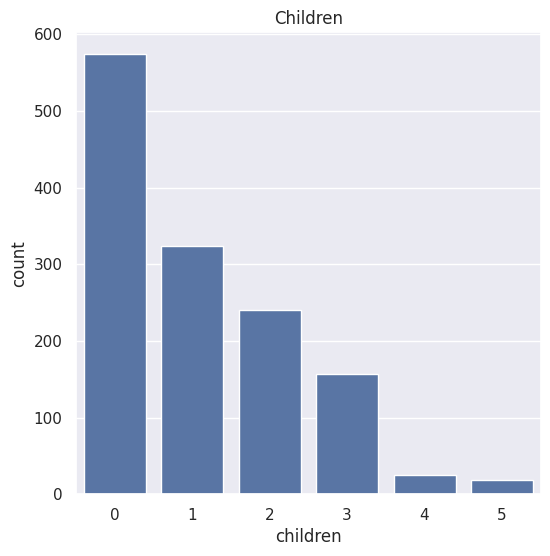

In [13]:
# children column
plt.figure(figsize=(6,6))
sns.countplot(x='children', data=insurance_dataset)
plt.title('Children')
plt.show()

In [14]:
insurance_dataset['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


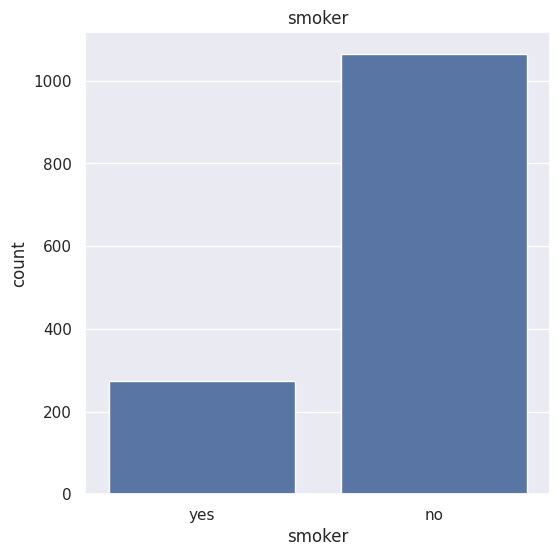

In [15]:
# smoker column
plt.figure(figsize=(6,6))
sns.countplot(x='smoker', data=insurance_dataset)
plt.title('smoker')
plt.show()

In [16]:
insurance_dataset['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


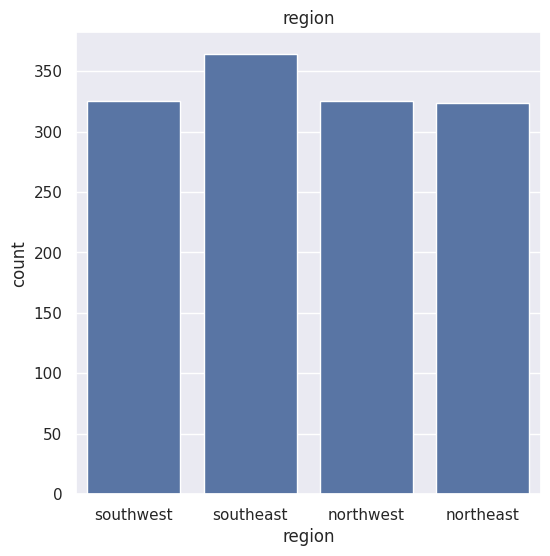

In [17]:
# region column
plt.figure(figsize=(6,6))
sns.countplot(x='region', data=insurance_dataset)
plt.title('region')
plt.show()

In [18]:
insurance_dataset['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


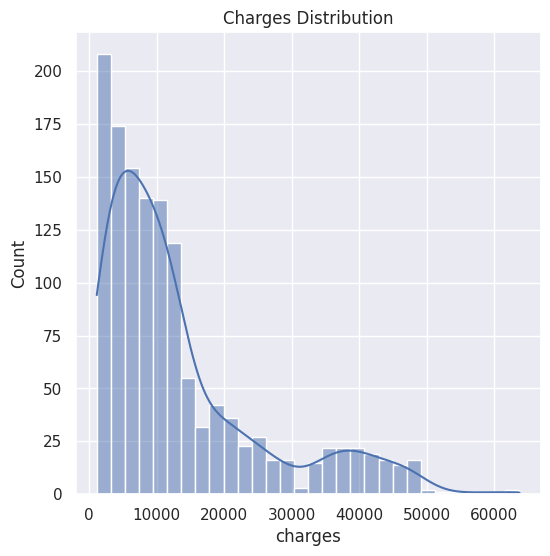

In [19]:
# distribution of charges value
plt.figure(figsize=(6,6))
sns.histplot(insurance_dataset['charges'], kde=True)
plt.title('Charges Distribution')
plt.show()

Data Pre-Processing

One-Hot Encoding the categorical features

We use `pd.get_dummies` instead of mapping categories to numbers like 0/1/2/3. Label-mapping `region` to 0–3 would imply a false order (that "northwest" is somehow greater than "southeast"). One-hot encoding creates a separate 0/1 column per category, so no fake ordering is introduced. `drop_first=True` removes one redundant column per feature.

In [20]:
# one-hot encode the categorical columns (sex, smoker, region)
# drop_first=True avoids redundant columns: e.g. sex -> single 'sex_male' column
insurance_dataset = pd.get_dummies(
    insurance_dataset,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

insurance_dataset.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Splitting the Features and Target

In [21]:
X = insurance_dataset.drop(columns='charges', axis=1)
Y = insurance_dataset['charges']

In [22]:
print(X)

      age     bmi  children  sex_male  smoker_yes  region_northwest  \
0      19  27.900         0     False        True             False   
1      18  33.770         1      True       False             False   
2      28  33.000         3      True       False             False   
3      33  22.705         0      True       False              True   
4      32  28.880         0      True       False              True   
...   ...     ...       ...       ...         ...               ...   
1333   50  30.970         3      True       False              True   
1334   18  31.920         0     False       False             False   
1335   18  36.850         0     False       False             False   
1336   21  25.800         0     False       False             False   
1337   61  29.070         0     False        True              True   

      region_southeast  region_southwest  
0                False              True  
1                 True             False  
2                 

In [23]:
print(Y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


Splitting the data into Training data & Testing Data

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [25]:
print(X.shape, X_train.shape, X_test.shape)

(1338, 8) (1070, 8) (268, 8)


Model Training

Linear Regression

In [26]:
# loading the Linear Regression model
regressor = LinearRegression()

In [27]:
regressor.fit(X_train, Y_train)

LinearRegression()

Model Evaluation

In [28]:
# prediction on training data
training_data_prediction =regressor.predict(X_train)

In [29]:
# R squared value
r2_train = metrics.r2_score(Y_train, training_data_prediction)
print('R squared vale : ', r2_train)

R squared vale :  0.7520187377309014


In [30]:
# prediction on test data
test_data_prediction =regressor.predict(X_test)

In [31]:
# R squared value
r2_test = metrics.r2_score(Y_test, test_data_prediction)
print('R squared vale : ', r2_test)

R squared vale :  0.7449415564623685


In [33]:
# describe one person in human-readable terms
input_dict = {
    'age': 31,
    'bmi': 25.74,
    'children': 0,
    'sex': 'male',
    'smoker': 'yes',
    'region': 'southwest',
}

# one-hot encode the input and align its columns to match the training features (X)
# reindex fills any dummy column not present in this single row with 0
input_df = pd.get_dummies(pd.DataFrame([input_dict]))
input_df = input_df.reindex(columns=X.columns, fill_value=0)

# predict using the best model selected above
prediction = regressor.predict(input_df)

print('The insurance cost is USD ', prediction[0])

The insurance cost is USD  27523.583214598937
